# 03 · Model training and evaluation

Three classifiers reclassify variants as **Pathogenic (1)** or **Benign (0)**:

| Model | Tuning | Why it is included |
|---|---|---|
| **XGBoost** | RandomizedSearchCV, 40 candidates × 5 folds, 9 hyperparameters | strong tabular baseline, handles interactions |
| **SVM, RBF kernel** | RandomizedSearchCV, 30 candidates × 5 folds (C, gamma, class weight) | smooth non-linear boundary, a different inductive bias |
| **FT-Transformer** | fixed architecture, early stopping | deep-learning model: self-attention across feature tokens |

Each model is saved as **one scikit-learn Pipeline** (preprocessing + classifier) in `models/*.joblib`, so production code passes raw columns and gets probabilities back.

**Overfitting guard.** Among search candidates, the winner is the best validation AUC whose train-to-validation gap is ≤ 0.03.
**Decision threshold.** Picked on out-of-fold *training* predictions by maximising Youden's J (sensitivity + specificity − 1), never on the test set.

In [1]:
# --- Setup: make the project package importable from notebooks/ -------------
import sys, warnings
from pathlib import Path
ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore")

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 160)

from src import config as cfg
print("Project root:", ROOT)

Project root: /home/claude/vus-reclassification


In [2]:
# Make sure the processed splits exist (runs the data stage if needed).
from src.data import make_dataset
if not cfg.TRAIN_FILE.exists():
    make_dataset.main()
from src.features import build_features as bf
if not cfg.SELECTED_FEATURES_FILE.exists():
    bf.run(); plt.close("all")   # rebuild selected features (fresh clone)

from src.models import train_model as tm
from src.models import evaluate_model as em

## 1. Search spaces and Transformer settings

In [3]:
print("XGBoost search space:")
for k, v in tm.XGB_SPACE.items():
    print(f"  {k.replace('clf__', ''):18s} {getattr(v, 'dist', v).name if hasattr(v, 'dist') else v}  {getattr(v, 'args', '')}")
print("\nSVM-RBF search space:")
for k, v in tm.SVM_SPACE.items():
    print(f"  {k.replace('clf__', ''):18s} {getattr(v, 'dist', v).name if hasattr(v, 'dist') else v}  {getattr(v, 'args', '')}")
print("\nFT-Transformer:", tm.TRANSFORMER_PARAMS)

XGBoost search space:
  n_estimators       randint  (100, 600)
  max_depth          randint  (2, 6)
  learning_rate      loguniform  (0.01, 0.2)
  subsample          uniform  (0.6, 0.4)
  colsample_bytree   uniform  (0.5, 0.5)
  min_child_weight   randint  (1, 30)
  gamma              uniform  (0, 5)
  reg_lambda         loguniform  (0.01, 20)
  reg_alpha          loguniform  (0.001, 5)

SVM-RBF search space:
  C                  loguniform  (0.01, 100.0)
  gamma              loguniform  (0.0001, 1)
  class_weight       [None, 'balanced']  

FT-Transformer: {'d_token': 32, 'n_heads': 4, 'n_layers': 2, 'ff_mult': 2, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 128, 'max_epochs': 200, 'patience': 20, 'random_state': 42}


## 2. Train (or load) the models
Training takes about 2 minutes on 2 CPU cores. Set `RETRAIN = True` to retrain; otherwise the saved joblib files are loaded.

In [4]:
RETRAIN = not all(p.exists() for p in cfg.MODEL_FILES.values())   # True -> retrain from scratch
if RETRAIN:
    tm.run(); plt.close("all")
models, meta = tm.load_models()
pd.DataFrame({m: {"CV AUC (out-of-fold)": v["oof_cv_auc"], "threshold": v["decision_threshold"],
                  "train seconds": v["train_seconds"]} for m, v in meta["models"].items()}).T.round(4)

,CV AUC (out-of-fold),threshold,train seconds
XGBoost,0.9286,0.2202,16.6
SVM-RBF,0.9329,0.2125,15.1
Transformer,0.9235,0.1057,73.8


In [5]:
for m, v in meta["models"].items():
    print(f"{m}: {v['best_params']}")

XGBoost: {'colsample_bytree': 0.5477050582452057, 'gamma': 1.8540912609913318, 'learning_rate': 0.07416218762063824, 'max_depth': 2, 'min_child_weight': 3, 'n_estimators': 271, 'reg_alpha': 0.22819491501562741, 'reg_lambda': 8.48625105707848, 'subsample': 0.7888859700647797}
SVM-RBF: {'C': 13.145103232150124, 'class_weight': None, 'gamma': 0.00042079886696066364, 'probability': True}
Transformer: {'d_token': 32, 'n_heads': 4, 'n_layers': 2, 'ff_mult': 2, 'dropout': 0.2, 'lr': 0.001, 'weight_decay': 0.0001, 'batch_size': 128, 'max_epochs': 200, 'patience': 20, 'random_state': 42}


## 3. Hyperparameter search and Transformer training curve

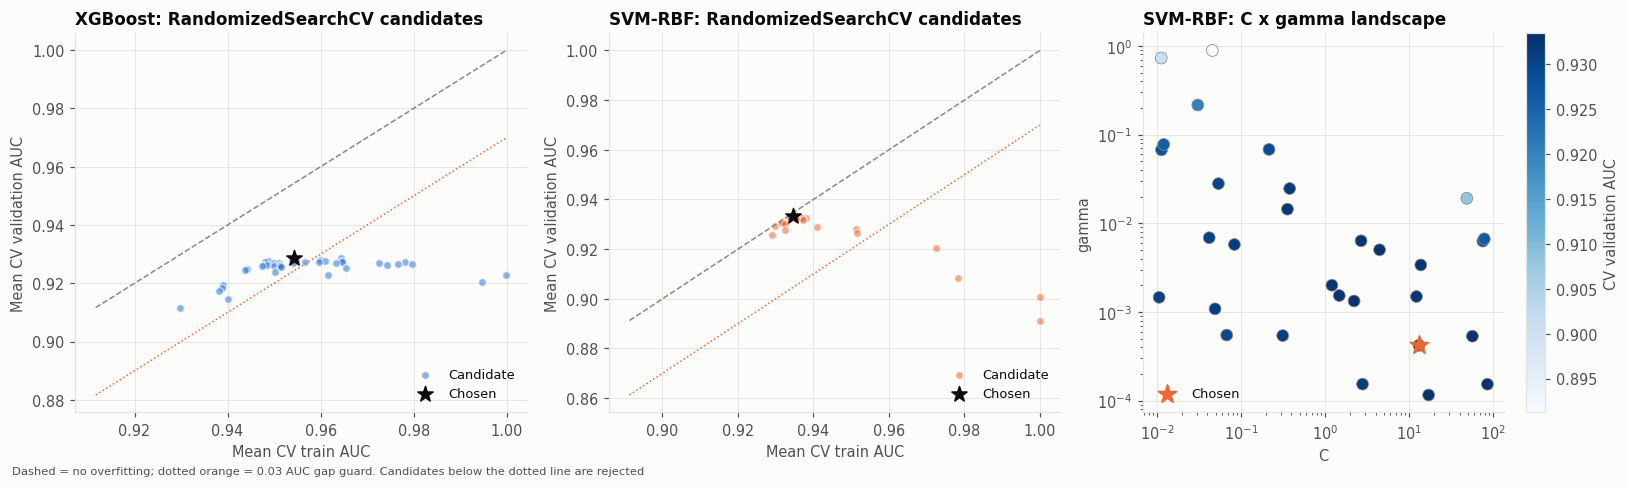

In [6]:
search = {n: pd.read_csv(cfg.TABLES_DIR / f"search_results_{n.lower().replace('-', '_')}.csv")
          for n in ["XGBoost", "SVM-RBF"]}
tm.plot_search(search);

In [7]:
display(search["XGBoost"].head(5).round(4))
display(search["SVM-RBF"].head(5).round(4))

,param_clf__colsample_bytree,param_clf__gamma,param_clf__learning_rate,param_clf__max_depth,param_clf__min_child_weight,param_clf__n_estimators,param_clf__reg_alpha,param_clf__reg_lambda,param_clf__subsample,mean_train_score,mean_test_score,std_test_score,gap,chosen
0,0.5477,1.8541,0.0742,2,3,271,0.2282,8.4863,0.7889,0.9543,0.9288,0.0064,0.0255,True
1,0.8172,3.4035,0.0491,3,6,515,0.1557,0.0185,0.7479,0.9645,0.9285,0.0059,0.0359,False
2,0.6528,0.9546,0.0224,4,18,380,0.0288,6.1203,0.9720,0.9600,0.9281,0.0081,0.0319,False
3,0.8485,3.5124,0.0294,2,10,346,0.0357,0.0701,0.8446,0.9538,0.9281,0.0079,0.0257,False
4,0.7434,4.5305,0.0367,2,1,383,0.2981,7.1227,0.6921,0.9487,0.9277,0.0066,0.0209,False


,param_clf__C,param_clf__class_weight,param_clf__gamma,mean_train_score,mean_test_score,std_test_score,gap,chosen
0,13.1451,NaN,0.0004,0.9346,0.9334,0.0035,0.0011,True
1,85.6887,NaN,0.0002,0.9349,0.9330,0.0038,0.0019,False
2,2.2233,NaN,0.0013,0.9341,0.9329,0.0042,0.0012,False
3,13.8262,NaN,0.0034,0.9380,0.9327,0.0044,0.0053,False
4,4.4678,balanced,0.0050,0.9371,0.9327,0.0047,0.0044,False


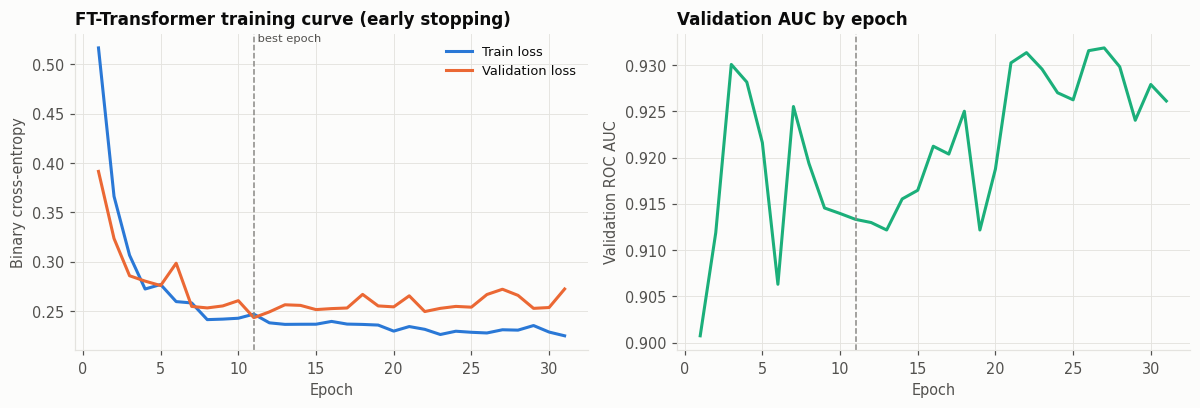

In [8]:
tm.plot_transformer_history(models["Transformer"].named_steps["clf"]);

## 4. Train vs Test comparison
All metrics use Pathogenic as the positive class and each model's own threshold.

In [9]:
from src.data.make_dataset import load_split, get_xy
feats = meta["features"]
Xtr, ytr = get_xy(load_split("train"), feats)
Xte, yte = get_xy(load_split("test"), feats)
tab = em.comparison_table(models, meta, {"Train": (Xtr, ytr), "Test": (Xte, yte)})
display(Markdown(em.to_markdown(tab)))

| Metric | XGBoost Train | XGBoost Test | SVM-RBF Train | SVM-RBF Test | Transformer Train | Transformer Test |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | 0.913 | 0.907 | 0.903 | 0.912 | 0.886 | 0.896 |
| Sensitivity | 0.940 | 0.912 | 0.912 | 0.912 | 0.930 | 0.934 |
| Specificity | 0.906 | 0.906 | 0.901 | 0.912 | 0.874 | 0.885 |
| PPV | 0.740 | 0.734 | 0.725 | 0.747 | 0.678 | 0.698 |
| NPV | 0.981 | 0.973 | 0.973 | 0.973 | 0.978 | 0.979 |
| AUC | 0.953 | 0.947 | 0.934 | 0.950 | 0.929 | 0.952 |
| F1 | 0.828 | 0.813 | 0.808 | 0.821 | 0.785 | 0.799 |

In [10]:
tab.pivot_table(index=["Model", "Set"], values=["Balanced_Accuracy", "MCC", "Brier", "TP", "FP", "TN", "FN"]).round(3)

Balanced_Accuracy  Brier    FN     FP    MCC      TN     TP
Model       Set                                                               
SVM-RBF     Test               0.912  0.070  12.0   42.0  0.770   436.0  124.0
            Train              0.907  0.073  48.0  189.0  0.753  1720.0  498.0
Transformer Test               0.909  0.060   9.0   55.0  0.744   423.0  127.0
            Train              0.902  0.067  38.0  241.0  0.726  1668.0  508.0
XGBoost     Test               0.909  0.072  12.0   45.0  0.760   433.0  124.0
            Train              0.923  0.061  33.0  180.0  0.781  1729.0  513.0

**Reading the table**

* Accuracy, sensitivity, specificity, NPV and AUC sit around 0.89–0.98 on **both** Train and Test, and Train and Test are within about 0.03 of each other, so there is no meaningful overfitting.
* PPV (≈0.70–0.75) and F1 (≈0.80–0.83) are lower. This is expected, not a defect: only 22% of labelled variants are Pathogenic, so even with ~91% specificity the false positives drawn from the large Benign group pull precision down. See the prevalence-shift stress test in notebook 04.

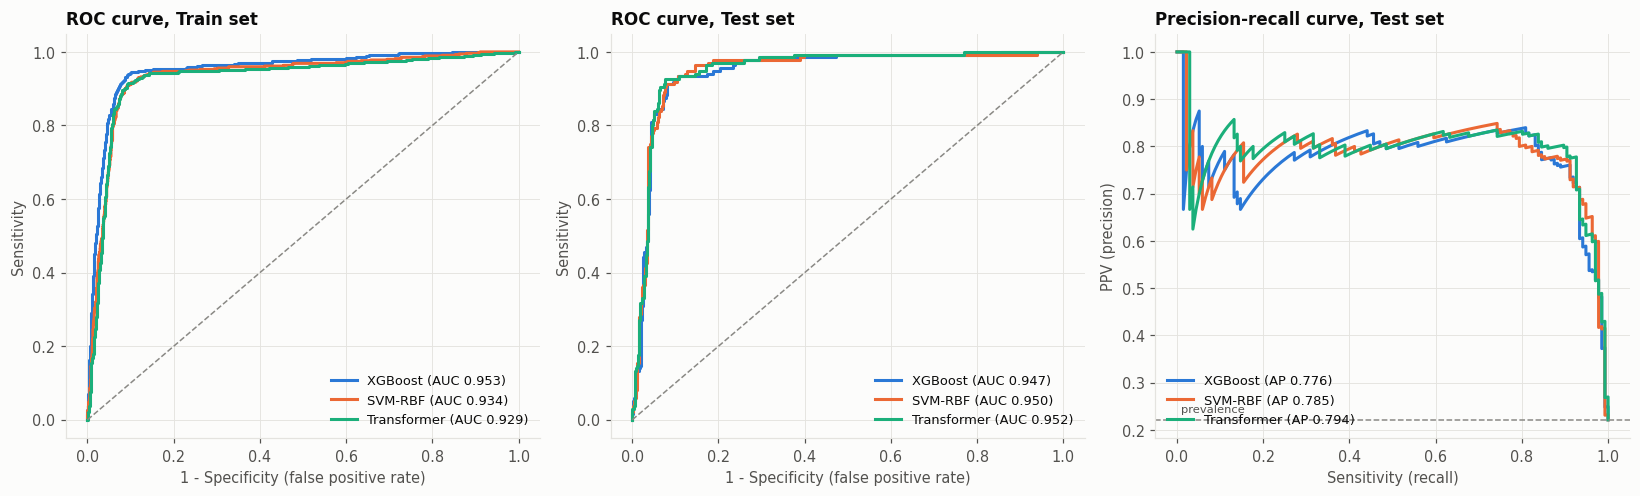

In [11]:
probs = {s: em.predict_all(models, X) for s, X in [("Train", Xtr), ("Test", Xte)]}
ys = {"Train": ytr.values, "Test": yte.values}
em.plot_roc_pr(probs, ys);

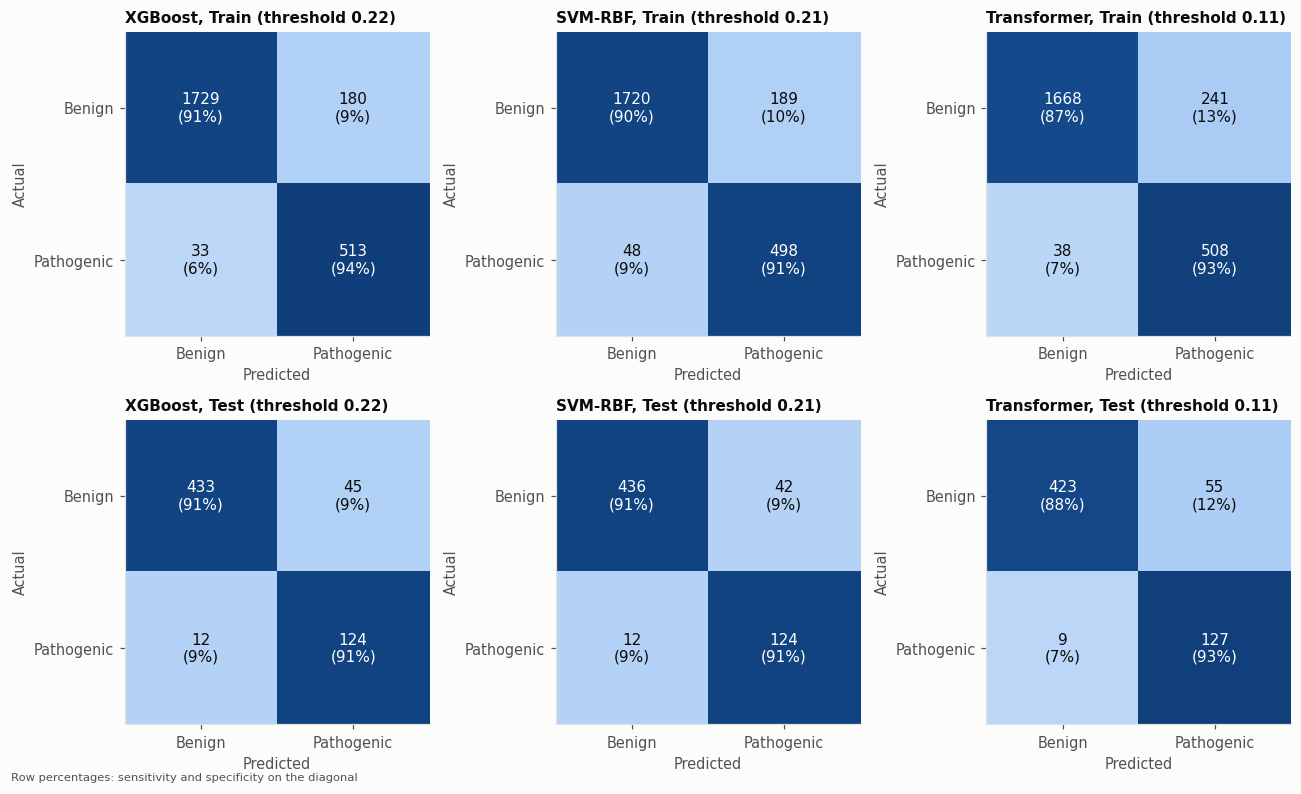

In [12]:
em.plot_confusion(tab);

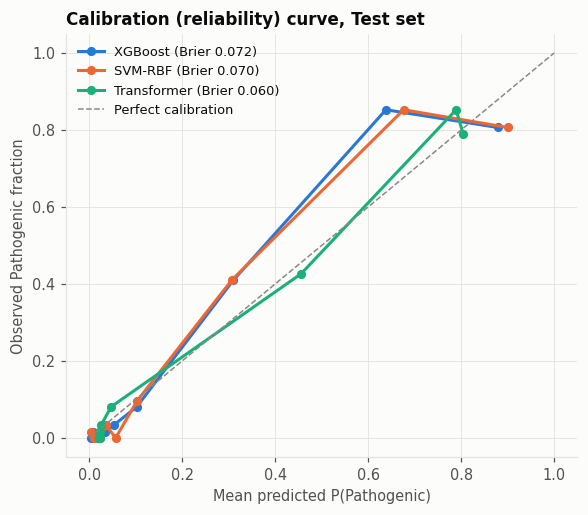

In [13]:
em.plot_calibration(probs, ys);

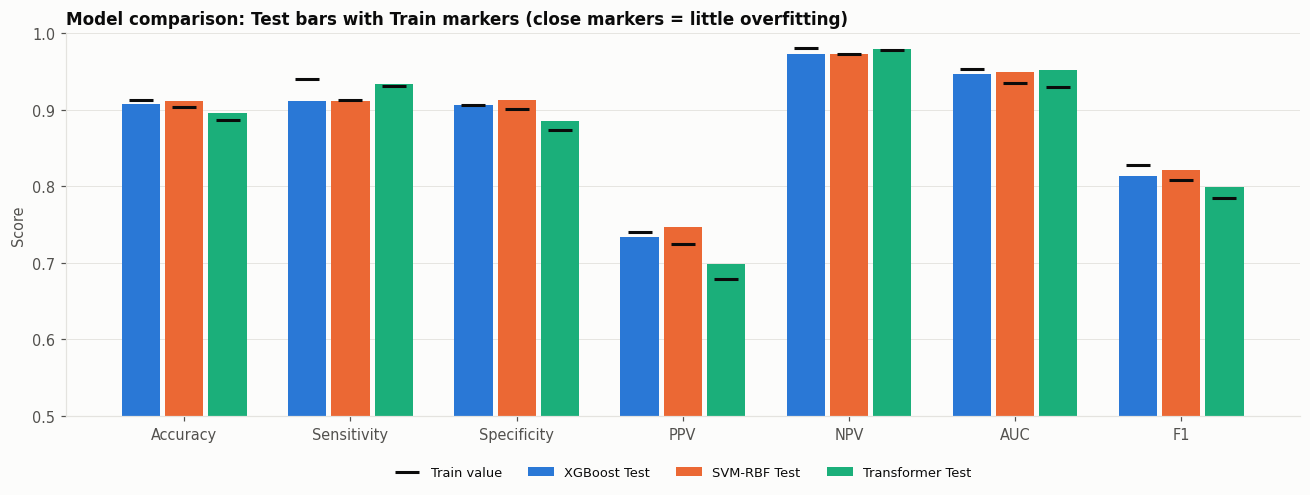

In [14]:
em.plot_metric_comparison(tab);

## 5. Feature importance
XGBoost's native gain importance (on the transformed columns), plus **permutation importance** for all three models: how much Test AUC drops when one original feature is shuffled. Permutation importance is model-agnostic, so the three models can be compared directly.

In_Functional_Domain_Yes     0.2346
Family_History_Cancer_Yes    0.1225
PolyPhen2_Score              0.0836
REVEL_Score                  0.0801
gnomAD_AF                    0.0676
Variant_Type_Nonsense        0.0587
Variant_Type_Frameshift      0.0419
SIFT_Score                   0.0397
HRD_Score                    0.0393
GERP_RS                      0.0343
dtype: float64

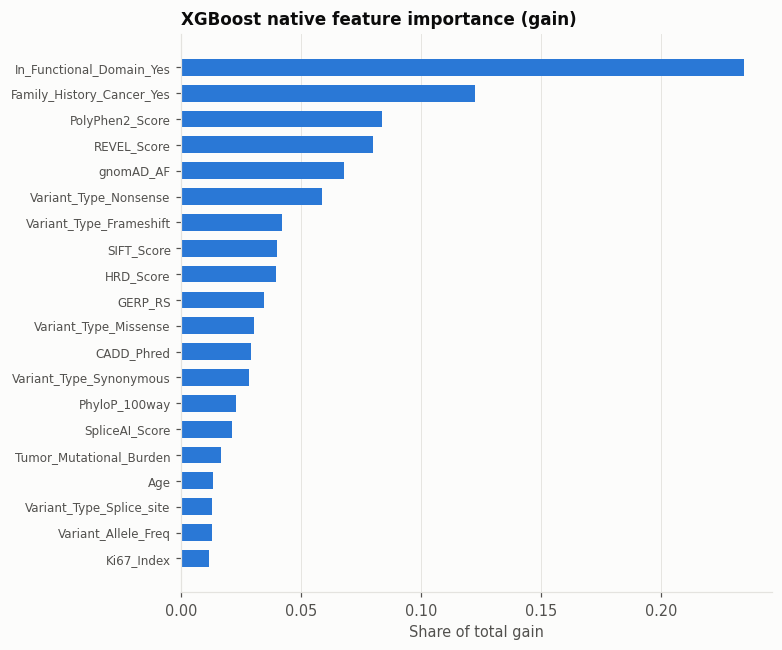

In [15]:
em.plot_xgb_importance(models["XGBoost"]).sort_values(ascending=False).head(10).round(4)

Model,SVM-RBF,Transformer,XGBoost
feature,,,
REVEL_Score,0.0061,0.0063,0.0120
Variant_Type,0.0057,0.0127,0.0111
PolyPhen2_Score,0.0083,0.0084,0.0108
In_Functional_Domain,0.0055,0.0111,0.0073
SpliceAI_Score,0.0022,0.0016,0.0048
GERP_RS,0.0042,0.0062,0.0045
CADD_Phred,0.0060,0.0074,0.0038
HRD_Score,0.0037,0.0078,0.0037
gnomAD_AF,0.0039,0.0055,0.0030


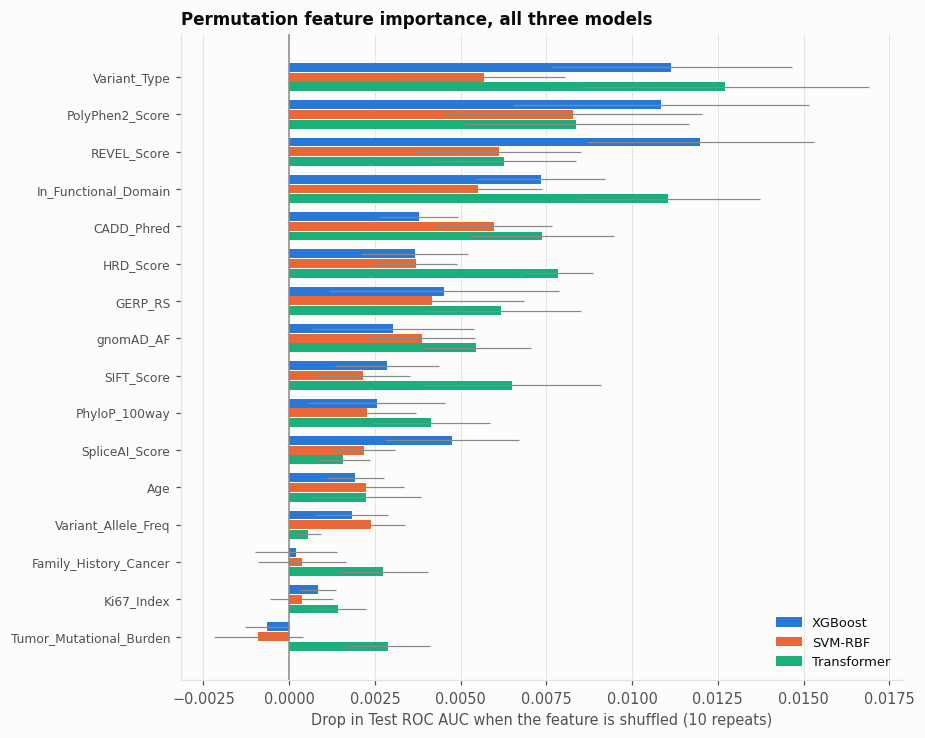

In [16]:
perm = em.permutation_table(models, Xte, yte)
em.plot_permutation(perm)
perm.pivot(index="feature", columns="Model", values="auc_drop_mean").sort_values("XGBoost", ascending=False).round(4)

All three models rely on the same core evidence: variant consequence, REVEL / PolyPhen-2 / CADD, functional-domain location, HRD score, conservation and population frequency. That agreement is itself a useful sanity check.

In [17]:
# Write every evaluation table and figure, exactly as `make evaluate` does
_ = em.run(); plt.close("all")

16:34:13 | INFO    | src.models.evaluate_model | Train/Test comparison:
| Metric | XGBoost Train | XGBoost Test | SVM-RBF Train | SVM-RBF Test | Transformer Train | Transformer Test |
|---|---:|---:|---:|---:|---:|---:|
| Accuracy | 0.913 | 0.907 | 0.903 | 0.912 | 0.886 | 0.896 |
| Sensitivity | 0.940 | 0.912 | 0.912 | 0.912 | 0.930 | 0.934 |
| Specificity | 0.906 | 0.906 | 0.901 | 0.912 | 0.874 | 0.885 |
| PPV | 0.740 | 0.734 | 0.725 | 0.747 | 0.678 | 0.698 |
| NPV | 0.981 | 0.973 | 0.973 | 0.973 | 0.978 | 0.979 |
| AUC | 0.953 | 0.947 | 0.934 | 0.950 | 0.929 | 0.952 |
| F1 | 0.828 | 0.813 | 0.808 | 0.821 | 0.785 | 0.799 |
